# 00i — Generate Digitization Assignments

Creates per-participant GeoJSON assignment files for the QGIS road-digitization workflow.

**What this notebook does:**
1. Loads UNHCR settlement boundary file from `data/processed/`.
2. Filters to one or more named settlements (or all of them).
3. Builds a 1 km × 1 km grid over each settlement plus an optional outward buffer.
4. Assigns standard attributes (`OID`, `poly_ids`, `Status`, `attribution`, `notes`) matching the QGIS digitizing plugin schema.
5. Distributes cells evenly across N participants using **snake-sort spatial ordering** (contiguous geographic chunks). Overlap cells for each participant pair are drawn from the geographic boundary between their chunks for QA.
6. Exports:
   - One GeoJSON per participant → `data/external/digitization_assignments/<name>.geojson`
   - A master GeoJSON with all cells → `data/external/digitization_assignments/grid_master.geojson`
7. Prints a summary table and draws an assignment map.

**To run for a new batch:** edit the *Parameters* cell and re-run all.


In [1]:
# ── Parameters — edit this cell; re-run all ─────────────────────────────────

# Settlement(s) to include.
# Use "ALL" to include every settlement in the boundary file,
# or pass a list of names, e.g. ["Nakivale", "Palabek", "Pagirinya"].
SETTLEMENTS = ["Palabek"]

# Digitizer roster.  Leave PARTICIPANT_NAMES empty ([]) to auto-generate
# names like "P1", "P2", …
N_DIGITIZERS = 3
PARTICIPANT_NAMES = []   # e.g. ["alice", "bob", "carol", "dave"]

# Grid geometry
GRID_SIZE_M      = 1000   # square cell side length in metres
OUTER_BUFFER_M   = 1000   # extend grid beyond settlement boundary

# Quality-control overlap: fraction of TOTAL cells shared between each participant pair
OVERLAP_PCT = 0.05

# Coordinate reference system (UTM 36N — correct for Uganda)
PROJECTED_CRS = "EPSG:32636"

# Set True to actually write files; False for a dry-run preview
EXPORT_RESULTS = False

# Output directory (relative to project root)
OUTPUT_SUBDIR = "data/external/digitization_assignments"


In [2]:
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import yaml
from shapely.geometry import Polygon

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (10, 10)

In [3]:
# ── Project paths ────────────────────────────────────────────────────────────

def find_project_root(start: Path | None = None) -> Path:
    """Walk upward until a directory containing configs/paths.yaml is found."""
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "configs" / "paths.yaml").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find configs/paths.yaml walking upward from the notebook directory."
    )


def load_project_paths(root: Path) -> dict:
    with open(root / "configs" / "paths.yaml") as f:
        return yaml.safe_load(f)


project_root = find_project_root()
paths = load_project_paths(project_root)

settlements_path = (
    project_root
    / paths["data"]["processed"]
    / "UNHCR_poc_boundaries-Uganda_attributed_deduped.geojson"
)
output_dir = project_root / OUTPUT_SUBDIR

print(f"Project root : {project_root}")
print(f"Settlements  : {settlements_path}")
print(f"Output dir   : {output_dir}")

Project root : C:\Users\Zachary\phd_classes\uganda
Settlements  : C:\Users\Zachary\phd_classes\uganda\data\processed\UNHCR_poc_boundaries-Uganda_attributed_deduped.geojson
Output dir   : C:\Users\Zachary\phd_classes\uganda\data\external\digitization_assignments


## 1. Load and filter settlements

In [4]:
def load_settlements(path: Path, crs: str) -> gpd.GeoDataFrame:
    gdf = gpd.read_file(path).to_crs(crs)
    gdf["settlement_name"] = gdf["name"].astype(str).str.strip()
    gdf["area_sqkm"] = gdf.geometry.area / 1e6
    return gdf.reset_index(drop=True)


def select_settlements(
    gdf: gpd.GeoDataFrame,
    selection,
) -> gpd.GeoDataFrame:
    """Return rows matching *selection* ("ALL" or list of names, case-insensitive)."""
    if isinstance(selection, str) and selection.upper() == "ALL":
        return gdf.copy()

    names_lower = [s.lower() for s in selection]
    mask = gdf["settlement_name"].str.lower().isin(names_lower)
    result = gdf[mask].copy()

    found = set(result["settlement_name"].str.lower())
    missing = [s for s in selection if s.lower() not in found]
    if missing:
        available = sorted(gdf["settlement_name"].unique())
        raise ValueError(
            f"Settlement(s) not found: {missing}.\nAvailable: {available}"
        )
    return result


settlements_all = load_settlements(settlements_path, PROJECTED_CRS)
selected = select_settlements(settlements_all, SETTLEMENTS)

print(f"Loaded {len(settlements_all)} settlements in boundary file.")
print(f"Selected {len(selected)} settlement(s) for this batch:\n")
display(
    selected[["settlement_name", "area_sqkm"]]
    .sort_values("area_sqkm", ascending=False)
    .reset_index(drop=True)
)

Loaded 30 settlements in boundary file.
Selected 1 settlement(s) for this batch:



,settlement_name,area_sqkm
0,Palabek,211.518165


## 2. Build 1 km grid

In [6]:
def _cells_for_polygon(polygon, cell_size: float, buffer_m: float) -> list:
    """Return square cells whose centroids fall inside the buffered polygon."""
    buffered = polygon.buffer(buffer_m)
    minx, miny, maxx, maxy = buffered.bounds
    cells = []
    for x in np.arange(minx, maxx, cell_size):
        for y in np.arange(miny, maxy, cell_size):
            cell = Polygon([
                (x, y),
                (x + cell_size, y),
                (x + cell_size, y + cell_size),
                (x, y + cell_size),
            ])
            if buffered.contains(cell.centroid):
                cells.append(cell)
    return cells


def build_master_grid(
    settlements_gdf: gpd.GeoDataFrame,
    cell_size: float,
    buffer_m: float,
) -> gpd.GeoDataFrame:
    """
    Build a global 1 km grid over all selected settlements.

    Attributes match the QGIS digitizing plugin schema:
      OID          — unique integer (0-indexed globally)
      poly_ids     — integer index of the settlement polygon the cell was built
                     from (matches the row position in *settlements_gdf*)
      settlement   — human-readable settlement name
      Status       — "todo" for all new cells
      attribution  — empty string (filled per-participant at export time)
      notes        — empty string
    """
    all_cells = []
    poly_ids  = []
    names     = []

    for local_idx, (_, row) in enumerate(settlements_gdf.iterrows()):
        cells = _cells_for_polygon(row.geometry, cell_size, buffer_m)
        all_cells.extend(cells)
        poly_ids.extend([local_idx] * len(cells))
        names.extend([row["settlement_name"]] * len(cells))

    grid = gpd.GeoDataFrame(
        {
            "poly_ids":    poly_ids,
            "settlement":  names,
            "Status":      "todo",
            "attribution": "",
            "notes":       "",
            "geometry":    all_cells,
        },
        crs=settlements_gdf.crs,
    ).reset_index(drop=True)

    grid.insert(0, "OID", np.arange(len(grid)))
    return grid


grid_master = build_master_grid(selected, GRID_SIZE_M, OUTER_BUFFER_M)

print(f"Master grid: {len(grid_master):,} cells")
print()
print(grid_master.groupby("settlement")["OID"].count().rename("n_cells").to_frame())
grid_master.head()

Master grid: 298 cells

            n_cells
settlement         
Palabek         298


,OID,poly_ids,settlement,Status,attribution,notes,geometry
0,0,0,Palabek,todo,,,"POLYGON ((428157.616 363991.334, 429157.616 36..."
1,1,0,Palabek,todo,,,"POLYGON ((428157.616 364991.334, 429157.616 36..."
2,2,0,Palabek,todo,,,"POLYGON ((429157.616 363991.334, 430157.616 36..."
3,3,0,Palabek,todo,,,"POLYGON ((429157.616 364991.334, 430157.616 36..."
4,4,0,Palabek,todo,,,"POLYGON ((430157.616 362991.334, 431157.616 36..."


C:\Users\Zachary\AppData\Local\Temp\ipykernel_60604\230082505.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", n_settle)


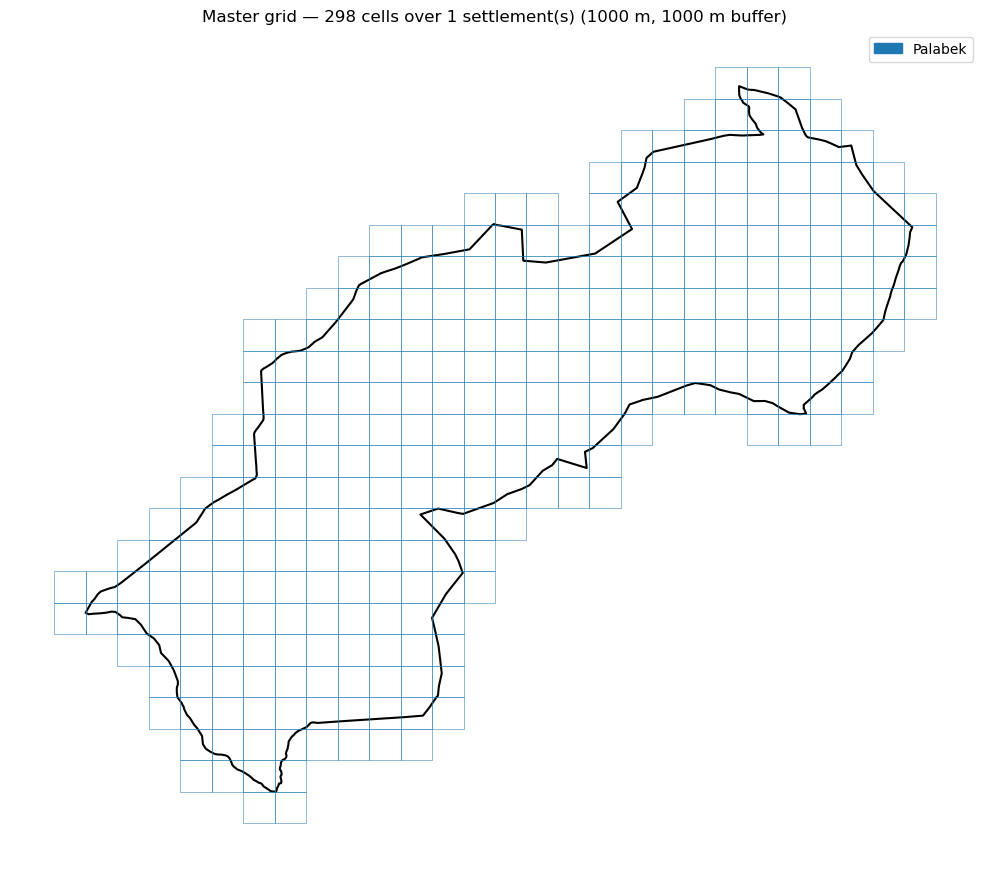

In [7]:
# Quick preview map
n_settle = len(selected)
cmap = plt.cm.get_cmap("tab10", n_settle)

fig, ax = plt.subplots(figsize=(10, 10))
for i, (_, s_row) in enumerate(selected.iterrows()):
    subset = grid_master[grid_master["poly_ids"] == i]
    subset.boundary.plot(ax=ax, color=cmap(i), linewidth=0.5, alpha=0.7)

selected.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.5)

patches = [
    mpatches.Patch(color=cmap(i), label=row["settlement_name"])
    for i, (_, row) in enumerate(selected.iterrows())
]
ax.legend(handles=patches, loc="upper right")
ax.set_title(
    f"Master grid — {len(grid_master):,} cells over "
    f"{n_settle} settlement(s) ({GRID_SIZE_M} m, {OUTER_BUFFER_M} m buffer)"
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 3. Assign cells to digitizers

In [8]:
from itertools import combinations

# Build participant name list
if PARTICIPANT_NAMES:
    if len(PARTICIPANT_NAMES) != N_DIGITIZERS:
        raise ValueError(
            f"PARTICIPANT_NAMES has {len(PARTICIPANT_NAMES)} entries "
            f"but N_DIGITIZERS is {N_DIGITIZERS}."
        )
    participants = PARTICIPANT_NAMES
else:
    participants = [f"P{i+1}" for i in range(N_DIGITIZERS)]

N = len(participants)
C = len(grid_master)
pairs = list(combinations(range(N), 2))
P = len(pairs)

# ── Overlap count per pair ────────────────────────────────────────────────────
# Math: N*n_unique + P*n_ov = C  →  each participant gets n_unique + (N-1)*n_ov
# If C is not divisible by N after removing the overlap pool, the remainder
# (0, 1, or 2 cells) goes to the first participants — totals may differ by ≤ 1.
n_ov = max(1, round(C * OVERLAP_PCT))
if P * n_ov >= C:
    raise ValueError(
        f"OVERLAP_PCT={OVERLAP_PCT} is too high: P*n_ov ({P*n_ov}) >= C ({C}). "
        "Lower OVERLAP_PCT."
    )

remaining_total = C - P * n_ov
n_unique_base   = remaining_total // N
leftover        = remaining_total % N   # ≤ N-1 extra cells

# ── Spatial sort: snake-sort cells by y-band then alternating x ───────────────
source = grid_master[["OID", "geometry"]].copy().reset_index(drop=True)
cx = source.geometry.centroid.x.values
cy = source.geometry.centroid.y.values
source["_cx"] = cx
source["_cy"] = cy

N_BANDS = max(10, N * 4)
y_min, y_max = cy.min(), cy.max()
x_min, x_max = cx.min(), cx.max()

source["_band"] = (
    (cy - y_min) / max(y_max - y_min, 1e-9) * N_BANDS
).astype(int).clip(0, N_BANDS - 1)

source["_xs"] = np.where(
    source["_band"] % 2 == 0,
    source["_cx"],
    x_max - source["_cx"] + x_min,
)

sorted_oids = source.sort_values(["_band", "_xs"])["OID"].tolist()
rank_of     = {oid: r for r, oid in enumerate(sorted_oids)}

# ── Overlap pools: cells near each pair's boundary in the sorted order ────────
chunk_centers = {k: (k + 0.5) * C / N for k in range(N)}

reserved      = set()
overlap_pools = {}

for (i, j) in pairs:
    mid_rank = (chunk_centers[i] + chunk_centers[j]) / 2
    avail = sorted(
        [(abs(rank_of[oid] - mid_rank), oid)
         for oid in sorted_oids if oid not in reserved]
    )
    chosen             = {oid for _, oid in avail[:n_ov]}
    overlap_pools[(i, j)] = chosen
    reserved          |= chosen

# ── Unique pools: remaining cells split into N contiguous chunks ──────────────
remaining = [oid for oid in sorted_oids if oid not in reserved]

unique_pools = {}
pos = 0
for k in range(N):
    size = n_unique_base + (1 if k < leftover else 0)
    unique_pools[k] = set(remaining[pos : pos + size])
    pos += size

# ── Final assignments ─────────────────────────────────────────────────────────
assignments_idx = {}
for k in range(N):
    assignments_idx[k] = set(unique_pools[k])
    for (i, j), pool in overlap_pools.items():
        if k in (i, j):
            assignments_idx[k] |= pool

sizes = [len(assignments_idx[k]) for k in range(N)]
assert max(sizes) - min(sizes) <= 1, "BUG: assignment sizes differ by more than 1."

# ── Per-cell assignment DataFrame ─────────────────────────────────────────────
all_overlap_oids = set().union(*overlap_pools.values())

cell_rows = []
for oid in source["OID"]:
    assigned = [participants[k] for k in range(N) if oid in assignments_idx[k]]
    cell_rows.append({
        "OID"        : oid,
        "assigned_to": assigned[0] if len(assigned) == 1 else ",".join(assigned),
        "is_overlap" : oid in all_overlap_oids,
    })
cell_assignment_df = pd.DataFrame(cell_rows)

# ── Per-participant summary ────────────────────────────────────────────────────
summary_rows = []
for k in range(N):
    row = {
        "participant" : participants[k],
        "unique_cells": len(unique_pools[k]),
        "total_cells" : len(assignments_idx[k]),
    }
    for (i, j), pool in overlap_pools.items():
        if k in (i, j):
            other = j if k == i else i
            row[f"shared_with_{participants[other]}_n"] = len(pool)
    summary_rows.append(row)

assignment_summary = pd.DataFrame(summary_rows)

print(
    f"C={C}  |  n_ov per pair={n_ov} ({100*n_ov/C:.1f}% of C)  |  "
    f"n_unique_base={n_unique_base}  |  leftover={leftover}"
)
print(f"Total cells per participant: {sizes}  (max diff = {max(sizes)-min(sizes)})")
print()
display(assignment_summary)


C=298  |  n_ov per pair=15 (5.0% of C)  |  n_unique_base=84  |  leftover=1
Total cells per participant: [115, 114, 114]  (max diff = 1)



,participant,unique_cells,total_cells,shared_with_P2_n,shared_with_P3_n,shared_with_P1_n
0,P1,85,115,15.0,15.0,NaN
1,P2,84,114,NaN,15.0,15.0
2,P3,84,114,15.0,NaN,15.0


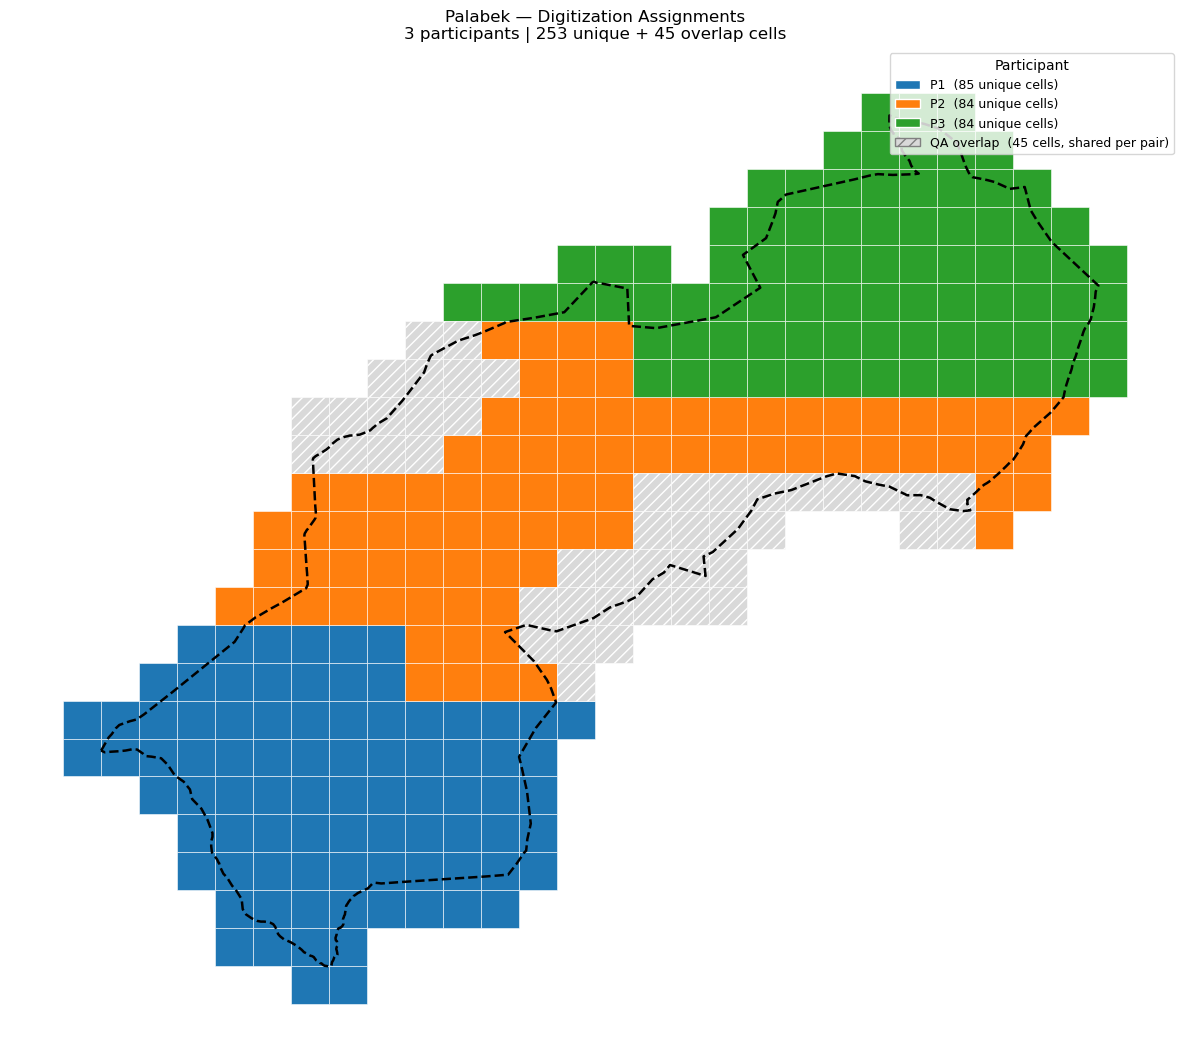

In [9]:
# ── Assignment map ────────────────────────────────────────────────────────────
OVERLAP_COLOR = "#d9d9d9"
cmap_p = plt.get_cmap("tab10")
participant_colors = {participants[k]: cmap_p(k) for k in range(N)}

map_gdf = (
    source[["OID", "geometry"]]
    .merge(cell_assignment_df[["OID", "assigned_to", "is_overlap"]], on="OID", how="left")
    .copy()
)

settlement_name_str = ", ".join(selected["settlement_name"].tolist())
n_unique_total = (cell_assignment_df["is_overlap"] == False).sum()
n_overlap_total = all_overlap_oids.__len__()

fig, ax = plt.subplots(figsize=(12, 12))

for label, color in participant_colors.items():
    subset = map_gdf[~map_gdf["is_overlap"] & (map_gdf["assigned_to"] == label)]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor="white", linewidth=0.4, zorder=2)

overlap_cells = map_gdf[map_gdf["is_overlap"]]
if not overlap_cells.empty:
    overlap_cells.plot(
        ax=ax, color=OVERLAP_COLOR, edgecolor="white",
        linewidth=0.4, hatch="///", zorder=3,
    )

selected.plot(ax=ax, color="none", edgecolor="black", linewidth=1.8, linestyle="--", zorder=4)

handles = [
    mpatches.Patch(
        facecolor=participant_colors[participants[k]], edgecolor="white",
        label=f"{participants[k]}  ({len(unique_pools[k])} unique cells)"
    )
    for k in range(N)
]
handles.append(
    mpatches.Patch(
        facecolor=OVERLAP_COLOR, edgecolor="gray", hatch="///",
        label=f"QA overlap  ({n_overlap_total} cells, shared per pair)",
    )
)
ax.legend(handles=handles, loc="upper right", title="Participant", fontsize=9)
ax.set_title(
    f"{settlement_name_str} — Digitization Assignments\n"
    f"{N} participants | {n_unique_total} unique + {n_overlap_total} overlap cells"
)
ax.set_axis_off()
plt.tight_layout()
plt.show()


## 4. Export

In [ ]:
# Columns to keep in exported files (matches QGIS plugin schema exactly)
EXPORT_COLS = ["OID", "poly_ids", "settlement", "Status", "attribution", "notes", "geometry"]

if EXPORT_RESULTS:
    output_dir.mkdir(parents=True, exist_ok=True)

    # Master grid (all cells, no attribution set)
    master_path = output_dir / "grid_master.geojson"
    grid_master[EXPORT_COLS].to_crs(4326).to_file(master_path, driver="GeoJSON")
    print(f"  master  → {master_path}")

    # Per-participant files
    for k, name in enumerate(participants):
        oids = assignments_idx[k]
        gdf = grid_master[grid_master["OID"].isin(oids)].copy()
        gdf["attribution"] = name
        gdf["Status"] = "todo"
        gdf["notes"] = ""
        out_cols = [c for c in EXPORT_COLS if c in gdf.columns]
        out_path = output_dir / f"{name}.geojson"
        gdf[out_cols].to_crs(4326).to_file(out_path, driver="GeoJSON")
        print(f"  {name:20s} → {out_path}  ({len(gdf):>4d} cells)")

    print(f"\nExported {1 + N} GeoJSON files to:\n  {output_dir}")

else:
    print("EXPORT_RESULTS = False — no files written.")
    print(f"Set EXPORT_RESULTS = True in the Parameters cell to write to:\n  {output_dir}")
